 CSC 301: Algorithm Analysis and Design Project

# k-Nearest Neighbors (KNN) Algorithm

## Algorithm Type
**Brute Force / Distance-Based**

## Problem Context
In this project, the k-Nearest Neighbors (KNN) algorithm is used to solve the **Heart Disease Prediction** problem, which is formulated as a **classification problem**.  
Given a dataset of patients described by several medical attributes, the goal is to determine whether a patient belongs to one of two classes: **having heart disease** or **not having heart disease**.

**KNN** was chosen because it represents a clear distance-based algorithmic approach and is suitable for performance analysis in terms of time complexity, space complexity, and scalability with input size.

In [20]:
# Import libraries
import pandas as pd             # for data loading and analysis
import matplotlib.pyplot as plt # for visualization

from sklearn.model_selection import train_test_split # function to split data into training and testing sets
from sklearn.preprocessing import StandardScaler     # used to normalize feature values for fair distance computation
from sklearn.neighbors import KNeighborsClassifier   # import KNN algorithm
from sklearn.metrics import accuracy_score           # functions to evaluate model performance

import time # used to measure execution time

In [21]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv("synthetic_heart_disease_dataset.csv")

# Display first 5 rows
df.head() 

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [22]:
# Display the shape
df.shape

(50000, 21)

In [23]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [24]:
# Check for missing values
df.isnull().sum()

Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64

In [25]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [26]:
# Drop Alcohol_Intake and Previous_Heart_Attack columns directly from the original DataFrame
df.drop(columns=["Alcohol_Intake", "Previous_Heart_Attack"], inplace=True)

In [27]:
# Select all columns with object (categorical) type
object_cols = df.select_dtypes(include="object").columns

# print unique values for each column 
for col in object_cols:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 40)

Column: Gender
['Male' 'Female']
----------------------------------------
Column: Smoking
['Never' 'Current' 'Former']
----------------------------------------
Column: Physical_Activity
['Sedentary' 'Active' 'Moderate']
----------------------------------------
Column: Diet
['Healthy' 'Average' 'Unhealthy']
----------------------------------------
Column: Stress_Level
['Medium' 'High' 'Low']
----------------------------------------


In [28]:
# Binary encoding
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})


# Ordinal encoding
df["Smoking"] = df["Smoking"].map({"Never": 0, "Former": 1, "Current": 2})

df["Physical_Activity"] = df["Physical_Activity"].map({"Sedentary": 0, "Moderate": 1, "Active": 2})

df["Diet"] = df["Diet"].map({"Unhealthy": 0, "Average": 1, "Healthy": 2})

df["Stress_Level"] = df["Stress_Level"].map({"Low": 0, "Medium": 1, "High": 2})

In [29]:
df.dtypes

Age                      int64
Gender                   int64
Weight                   int64
Height                   int64
BMI                    float64
Smoking                  int64
Physical_Activity        int64
Diet                     int64
Stress_Level             int64
Hypertension             int64
Diabetes                 int64
Hyperlipidemia           int64
Family_History           int64
Systolic_BP              int64
Diastolic_BP             int64
Heart_Rate               int64
Blood_Sugar_Fasting      int64
Cholesterol_Total        int64
Heart_Disease            int64
dtype: object

In [30]:
# Store input sizes 
small_sizes = [100, 500, 1000, 2000]

# Store all running times for each input size
small_results = {}
small_all_times = {}

# Loop over the specified sizes
for size in small_sizes:
    times = []
    print(f"\n** Input size = {size} **")
    df_sample = df.sample(n=size)                  # Extract sample dataset
    X = df_sample.drop("Heart_Disease", axis=1)    # Select all features except the target column
    y = df_sample["Heart_Disease"]                 # Select the target column
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Split the dataset: 80% for training and 20% for testing

    scaler = StandardScaler()                      # Create a scaler object to normalize the data
    X_train = scaler.fit_transform(X_train)        # Fit scaler on training data and transform it
    X_test = scaler.transform(X_test)              # Apply the same transformation to test data
    
    
    # Do the experiment 20 times
    for i in range(1,21):
        knn = KNeighborsClassifier(n_neighbors=5) # Initialize KNN model with k = 5 neighbors
        start_time = time.perf_counter()          # The start time of the algorithm
        knn.fit(X_train, y_train)                 # Train the KNN model using training data
        y_pred = knn.predict(X_test)              # Predict class labels for test data
        end_time = time.perf_counter()            # The end time of the algorithm

        running_time = (end_time - start_time) * 1000   # Print the running time of the algorithm

        times.append(running_time)                # Store running times
        print(f"Run {i}: {running_time:.3f} ms")  # Print each experiment runnning time
        
    # Find best, average, worst cases and store them   
    best = min(times)
    worst = max(times)
    avg = sum(times) / len(times)

    # Store all 20 running times for this input size
    small_results[size] = (best, avg, worst)
    small_all_times[size] = times
    
    # Print all cases for each input size
    print("\n--- Running cases ---")
    print(f"Best case: {best:.3f} ms")
    print(f"Average case: {avg:.3f} ms")
    print(f"Worst case: {worst:.3f} ms")


** Input size = 100 **
Run 1: 5.380 ms
Run 2: 6.293 ms
Run 3: 6.933 ms
Run 4: 6.054 ms
Run 5: 6.247 ms
Run 6: 6.861 ms
Run 7: 5.941 ms
Run 8: 6.732 ms
Run 9: 6.177 ms
Run 10: 5.495 ms
Run 11: 5.955 ms
Run 12: 5.888 ms
Run 13: 6.517 ms
Run 14: 6.044 ms
Run 15: 6.771 ms
Run 16: 6.159 ms
Run 17: 5.955 ms
Run 18: 5.862 ms
Run 19: 5.656 ms
Run 20: 5.371 ms

--- Running cases ---
Best case: 5.371 ms
Average case: 6.115 ms
Worst case: 6.933 ms

** Input size = 500 **
Run 1: 7.002 ms
Run 2: 7.315 ms
Run 3: 7.737 ms
Run 4: 7.683 ms
Run 5: 7.208 ms
Run 6: 7.328 ms
Run 7: 7.662 ms
Run 8: 7.120 ms
Run 9: 7.106 ms
Run 10: 7.503 ms
Run 11: 7.326 ms
Run 12: 8.262 ms
Run 13: 7.169 ms
Run 14: 7.518 ms
Run 15: 7.104 ms
Run 16: 6.580 ms
Run 17: 6.233 ms
Run 18: 6.942 ms
Run 19: 6.849 ms
Run 20: 6.891 ms

--- Running cases ---
Best case: 6.233 ms
Average case: 7.227 ms
Worst case: 8.262 ms

** Input size = 1000 **
Run 1: 8.612 ms
Run 2: 8.323 ms
Run 3: 8.604 ms
Run 4: 9.862 ms
Run 5: 9.293 ms
Run 6: 10.7

In [31]:
# Store input sizes 
large_sizes = [10000, 20000, 30000, 40000]

# Store all running times for each input size
large_results = {}
large_all_times = {}

# Loop over the specified sizes
for size in large_sizes:
    times = []
    print(f"\n** Input size = {size} **")
    df_sample = df.sample(n=size)                  # Extract sample dataset
    X = df_sample.drop("Heart_Disease", axis=1)    # Select all features except the target column
    y = df_sample["Heart_Disease"]                 # Select the target column
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Split the dataset: 80% for training and 20% for testing

    scaler = StandardScaler()                      # Create a scaler object to normalize the data
    X_train = scaler.fit_transform(X_train)        # Fit scaler on training data and transform it
    X_test = scaler.transform(X_test)              # Apply the same transformation to test data
    
    
    # Do the experiment 20 times
    for i in range(1,21):
        knn = KNeighborsClassifier(n_neighbors=5) # Initialize KNN model with k = 5 neighbors
        start_time = time.perf_counter()          # The start time of the algorithm
        knn.fit(X_train, y_train)                 # Train the KNN model using training data
        y_pred = knn.predict(X_test)              # Predict class labels for test data
        end_time = time.perf_counter()            # The end time of the algorithm

        running_time = (end_time - start_time) * 1000   # Print the running time of the algorithm

        times.append(running_time)                # Store running times
        print(f"Run {i}: {running_time:.3f} ms")  # Print each experiment runnning time
        
    #  Find best, average, worst cases and store them   
    best = min(times)
    worst = max(times)
    avg = sum(times) / len(times)

    # Store all 20 running times for this input size
    large_results[size] = (best, avg, worst)
    large_all_times[size] = times
    
    # Print all cases for each input size
    print("\n--- Running cases ---")
    print(f"Best case: {best:.3f} ms")
    print(f"Average case: {avg:.3f} ms")
    print(f"Worst case: {worst:.3f} ms")


** Input size = 10000 **
Run 1: 24.018 ms
Run 2: 23.425 ms
Run 3: 26.111 ms
Run 4: 24.461 ms
Run 5: 22.709 ms
Run 6: 23.625 ms
Run 7: 22.840 ms
Run 8: 19.480 ms
Run 9: 19.328 ms
Run 10: 18.178 ms
Run 11: 20.693 ms
Run 12: 22.448 ms
Run 13: 19.581 ms
Run 14: 19.341 ms
Run 15: 20.115 ms
Run 16: 20.704 ms
Run 17: 19.530 ms
Run 18: 21.842 ms
Run 19: 19.305 ms
Run 20: 21.862 ms

--- Running cases ---
Best case: 18.178 ms
Average case: 21.480 ms
Worst case: 26.111 ms

** Input size = 20000 **
Run 1: 49.516 ms
Run 2: 42.027 ms
Run 3: 37.566 ms
Run 4: 47.190 ms
Run 5: 46.834 ms
Run 6: 40.973 ms
Run 7: 36.818 ms
Run 8: 44.658 ms
Run 9: 41.552 ms
Run 10: 45.612 ms
Run 11: 41.457 ms
Run 12: 41.884 ms
Run 13: 42.057 ms
Run 14: 34.933 ms
Run 15: 39.158 ms
Run 16: 41.708 ms
Run 17: 43.233 ms
Run 18: 39.114 ms
Run 19: 43.009 ms
Run 20: 40.428 ms

--- Running cases ---
Best case: 34.933 ms
Average case: 41.986 ms
Worst case: 49.516 ms

** Input size = 30000 **
Run 1: 78.524 ms
Run 2: 78.454 ms
Run 3:

In [32]:
def create_knn_main_table(all_times_dict):
    if not all_times_dict:
        raise ValueError("all_times_dict is empty. Please run the experiment cell first.")

    table_data = {}

    for size, times in all_times_dict.items():
        table_data[size] = times

    df_table = pd.DataFrame(table_data, index=[f"Time {i} (ms)" for i in range(1, 21)])     # Create table of recorded times

    experimental_avg = [sum(all_times_dict[size]) / len(all_times_dict[size]) for size in all_times_dict.keys()]
    df_table.loc["Experimental Average"] = experimental_avg    # Compute average time

    theoretical = [size for size in all_times_dict.keys()]     # Theoretical estimate for KNN assuming linear time complexity O(n)
    scale_factor = experimental_avg[-1] / theoretical[-1]      # Scale theoretical values to match experimental results

    theoretical_scaled = [x * scale_factor for x in theoretical]
    df_table.loc["Theoretical Estimate"] = theoretical_scaled  # Store scaled theoretical estimates

    # Compare experimental results with theoretical estimates
    ratio = [experimental_avg[i] / theoretical_scaled[i] for i in range(len(experimental_avg))]
    df_table.loc["Experimental/Theory"] = ratio

    return df_table.round(4)

In [33]:
small_main_table = create_knn_main_table(small_all_times)

print("SMALL INPUTS - MAIN TABLE")
display(small_main_table)

SMALL INPUTS - MAIN TABLE


,100,500,1000,2000
Time 1 (ms),5.3804,7.0024,8.6116,16.7282
Time 2 (ms),6.2930,7.3149,8.3232,16.5954
Time 3 (ms),6.9335,7.7367,8.6043,16.3715
Time 4 (ms),6.0543,7.6830,9.8623,16.6024
Time 5 (ms),6.2469,7.2079,9.2928,17.5616
Time 6 (ms),6.8610,7.3275,10.7527,16.3915
Time 7 (ms),5.9408,7.6624,8.7525,16.8796
Time 8 (ms),6.7321,7.1205,9.9971,16.6655
Time 9 (ms),6.1766,7.1058,9.4446,16.5138
Time 10 (ms),5.4949,7.5030,9.3120,16.9496


In [34]:
large_main_table = create_knn_main_table(large_all_times)

print("LARGE INPUTS - MAIN TABLE")
display(large_main_table)

LARGE INPUTS - MAIN TABLE


,10000,20000,30000,40000
Time 1 (ms),24.0180,49.5165,78.5239,129.7379
Time 2 (ms),23.4249,42.0274,78.4544,130.2522
Time 3 (ms),26.1115,37.5656,84.1778,142.5764
Time 4 (ms),24.4609,47.1899,87.2325,135.7537
Time 5 (ms),22.7094,46.8338,84.3602,117.3684
Time 6 (ms),23.6252,40.9728,82.5647,141.5882
Time 7 (ms),22.8399,36.8181,75.6650,136.5656
Time 8 (ms),19.4796,44.6583,79.3862,133.5034
Time 9 (ms),19.3280,41.5518,82.5623,122.3798
Time 10 (ms),18.1780,45.6115,79.5293,117.6736


## Experimental Results

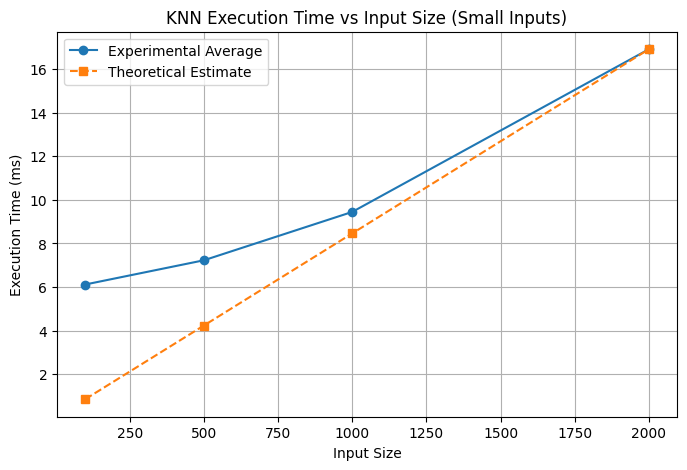

In [35]:
# KNN Small Inputs Diagram
small_avg_times = [small_results[size][1] for size in small_sizes] # Get average running time for each small input size
small_theoretical = [size for size in small_sizes]                 # Theoretical growth for KNN is O(n)
scale_factor_small = small_avg_times[-1] / small_theoretical[-1]   # Scale theoretical values to match experimental results
small_theoretical_scaled = [x * scale_factor_small for x in small_theoretical] # Apply scaling to theoretical values

plt.figure(figsize=(8, 5))
plt.plot(small_sizes, small_avg_times, marker='o', label='Experimental Average')
plt.plot(small_sizes, small_theoretical_scaled, marker='s', linestyle='--', label='Theoretical Estimate')

plt.title("KNN Execution Time vs Input Size (Small Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")

plt.grid(True)
plt.legend()
plt.show()

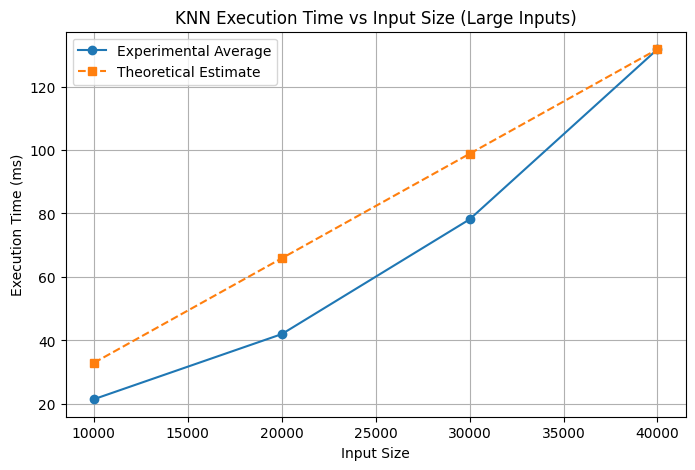

In [36]:
# KNN Large Inputs Diagram

large_avg_times = [large_results[size][1] for size in large_sizes] # Get average running time for each large input size
large_theoretical = [size for size in large_sizes]                 # Theoretical growth for KNN is O(n)
scale_factor_large = large_avg_times[-1] / large_theoretical[-1]   # Scale theoretical values to match experimental results
large_theoretical_scaled = [x * scale_factor_large for x in large_theoretical] # Apply scaling to theoretical values

plt.figure(figsize=(8, 5))
plt.plot(large_sizes, large_avg_times, marker='o', label='Experimental Average')
plt.plot(large_sizes, large_theoretical_scaled, marker='s', linestyle='--', label='Theoretical Estimate')

plt.title("KNN Execution Time vs Input Size (Large Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")

plt.grid(True)
plt.legend()
plt.show()

### Plot for the values reported in the submission

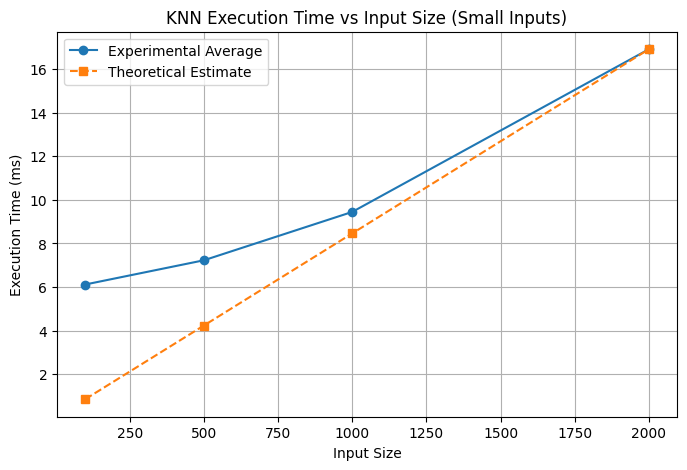

In [37]:
# Small input sizes
small_sizes = [100, 500, 1000, 2000]

# Experimental average and theoretical values reported in the previous submission report
small_avg_times_previous = [12.0645, 18.9019, 45.7518, 85.0488]
small_theoretical_previous = [4.2524, 21.2622, 42.5244, 85.0488]

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(small_sizes, small_avg_times, marker='o', label='Experimental Average')
plt.plot(small_sizes, small_theoretical_scaled, marker='s', linestyle='--', label='Theoretical Estimate')

plt.title("KNN Execution Time vs Input Size (Small Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.show()

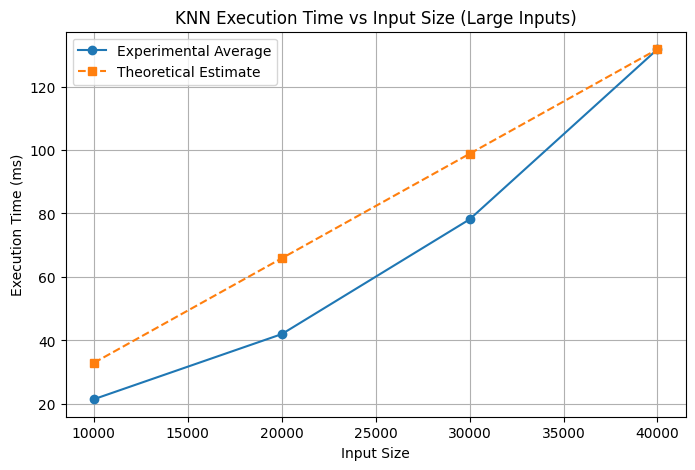

In [38]:
# Large input sizes
large_sizes = [10000, 20000, 30000, 40000]

# Experimental average and theoretical values reported in the previous submission report
large_avg_times_previous = [359.6838, 989.7525, 1680.7196, 2875.1486]
large_theoretical_previous = [718.7871, 1437.5743, 2156.3614, 2875.1486]

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(large_sizes, large_avg_times, marker='o', label='Experimental Average')
plt.plot(large_sizes, large_theoretical_scaled, marker='s', linestyle='--', label='Theoretical Estimate')

plt.title("KNN Execution Time vs Input Size (Large Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.show()